<a href="https://colab.research.google.com/github/Mohsin-22/Mohsin-22-Assignment4-100_Gen-Ai_cohort/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment 4**: Build a Semantic Search Ready NLP Pipeline from Raw Text Data.

In [1]:

!pip install nltk spacy gensim datasets scikit-learn matplotlib seaborn
!python -m spacy download en_core_web_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 80.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:

import re
import nltk
import spacy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import Word2Vec


In [3]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
nlp_engine = spacy.load("en_core_web_sm")
stop_words_set = set(stopwords.words("english"))


In [5]:
raw_dataset = load_dataset("amazon_polarity", split="train[:2000]")
feedback_texts = [item["content"] for item in raw_dataset]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [6]:
def clean_sentence(text_line):
    text_line = text_line.lower()
    text_line = re.sub(r"http\S+|www\S+", "", text_line)
    text_line = re.sub(r"[^a-z\s]", "", text_line)
    text_line = re.sub(r"\s+", " ", text_line)
    return text_line.strip()

cleaned_text_data = [clean_sentence(text) for text in feedback_texts]

In [7]:
def preprocess_text(sentence):
    doc = nlp_engine(sentence)
    processed_tokens = [
        token.lemma_
        for token in doc
        if token.text not in stop_words_set
        and token.is_alpha
        and len(token.text) > 2
    ]
    return processed_tokens

In [8]:
final_tokens_list = [preprocess_text(text) for text in cleaned_text_data]
final_sentences = [" ".join(tokens) for tokens in final_tokens_list]

In [9]:
unique_vocab = set()
for tokens in final_tokens_list:
    unique_vocab.update(tokens)

print("Vocabulary size:", len(unique_vocab))

Vocabulary size: 10917


In [10]:
bow_vectorizer = CountVectorizer(max_features=3000)
bow_matrix = bow_vectorizer.fit_transform(final_sentences)

In [11]:
tfidf_vectorizer = TfidfVectorizer(max_features=3000)
tfidf_matrix = tfidf_vectorizer.fit_transform(final_sentences)

In [12]:
word2vec_model = Word2Vec(
    sentences=final_tokens_list,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

In [13]:
def create_sentence_vector(tokens, model):
    valid_vectors = [
        model.wv[word] for word in tokens if word in model.wv
    ]
    if len(valid_vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(valid_vectors, axis=0)

sentence_vectors = np.array([
    create_sentence_vector(tokens, word2vec_model)
    for tokens in final_tokens_list
])

In [14]:
def find_similar_feedback(query_text, top_k=5):
    cleaned_query = clean_sentence(query_text)
    query_tokens = preprocess_text(cleaned_query)
    query_vector = create_sentence_vector(query_tokens, word2vec_model)

    similarity_scores = cosine_similarity(
        [query_vector],
        sentence_vectors
    )[0]

    top_indices = similarity_scores.argsort()[-top_k:][::-1]

    for idx in top_indices:
        print("Score:", round(similarity_scores[idx], 3))
        print("Text:", feedback_texts[idx][:200])
        print("-" * 80)

In [15]:
find_similar_feedback("poor customer service and bad support response overall Worst experience")

Score: 1.0
Text: If you enjoy bad scripts, bad actors poor film quality that was the early 70's, this is right up your alley.
--------------------------------------------------------------------------------
Score: 1.0
Text: I watched this last night. And I don't remember enough of it to give it a indepth review. But it wasn't as bad as people are letting on nor was it as great as people are letting on. If you don't like 
--------------------------------------------------------------------------------
Score: 1.0
Text: Let me start out by saying that I enjoy Adam Sandler movies. I like Billy Madison and Happy Gilmore. Sure, they're not great films, but they've given me plenty of laughs. So when I tell you that this 
--------------------------------------------------------------------------------
Score: 1.0
Text: I know bad music when I hear it. Here 'tis. The lead singer is the main problem, the band are not too bad, just apparently under the leadership of this mo. Go back to mommy and d

In [16]:
tfidf_mean_scores = np.array(tfidf_matrix.mean(axis=0)).flatten()
feature_names = tfidf_vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame({
    "word": feature_names,
    "avg_score": tfidf_mean_scores
}).sort_values(by="avg_score", ascending=False).head(15)

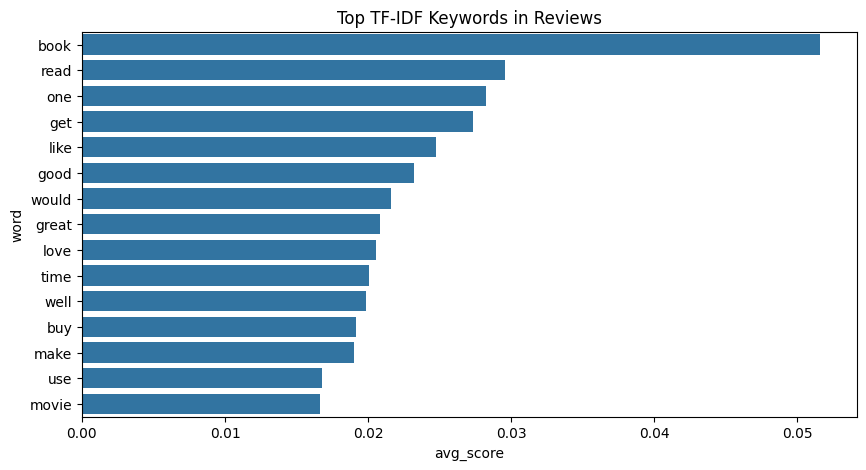

In [17]:
plt.figure(figsize=(10,5))
sns.barplot(data=tfidf_df, x="avg_score", y="word")
plt.title("Top TF‑IDF Keywords in Reviews")
plt.show()

# I have built an end‑to‑end NLP pipeline that cleans raw customer reviews, standardizes language using lemmatization, converts text into numerical representations using TF‑IDF and Word2Vec embeddings, and performs semantic similarity search using cosine similarity. The final visualization validates the importance of domain‑specific keywords